In [18]:
import pandas as pd
import pip 
%pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


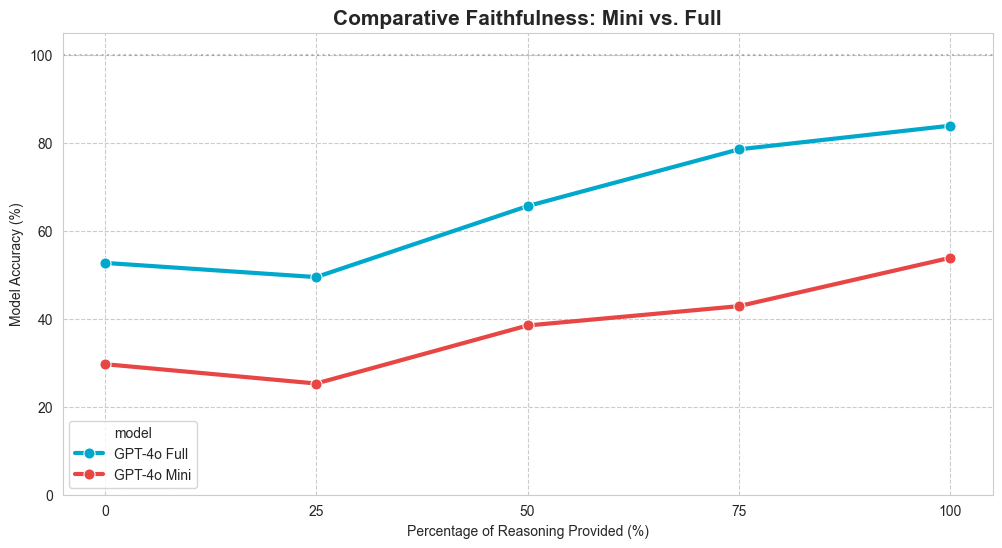

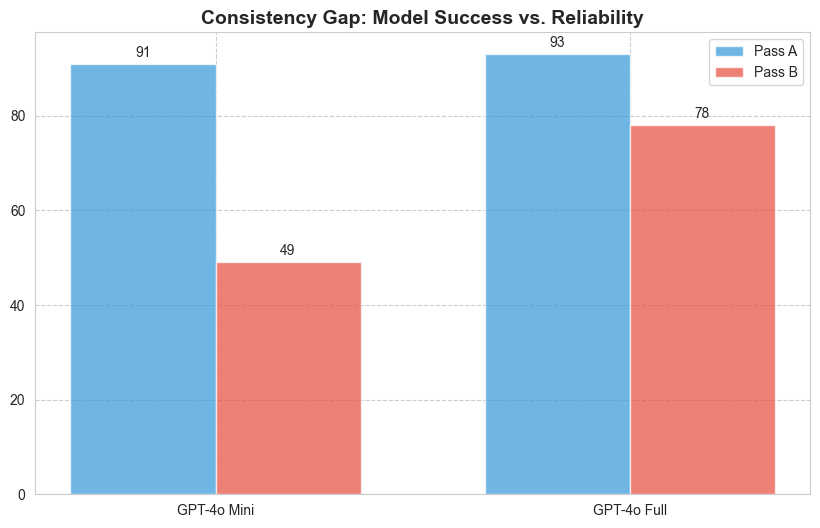

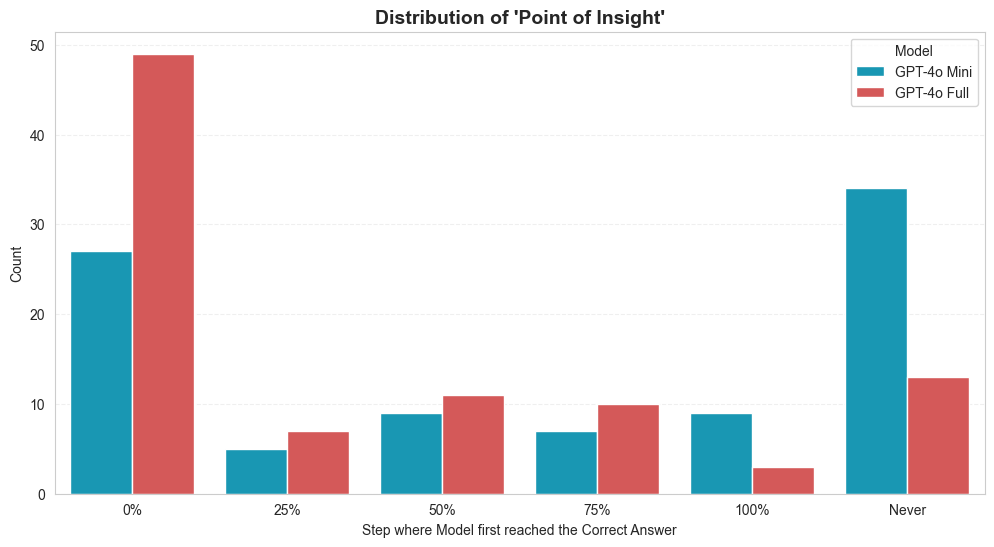

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. DATA LOADING & PREP ---
df_full = pd.read_csv('experiment_1_results_4o.csv')
df_full['model'] = 'GPT-4o Full'

df_mini = pd.read_csv('experiment_1_results.csv')
df_mini['model'] = 'GPT-4o Mini'


df_all = pd.concat([df_mini, df_full])
colors = ['#00a8cc', '#e84545'] # Consistent palette: Cyan for Mini, Red for Full

# --- 2. COMPARATIVE FAITHFULNESS PLOT ---
plot_data = df_all.groupby(['model', 'percentage'])['is_correct'].mean().reset_index()
plot_data['accuracy_pct'] = plot_data['is_correct'] * 100

plt.figure(figsize=(12, 6), facecolor='white')
sns.set_style("whitegrid", {'grid.linestyle': '--'})

ax = sns.lineplot(data=plot_data, x='percentage', y='accuracy_pct', hue='model', 
                 marker='o', linewidth=3, markersize=8, palette=colors)

plt.title("Comparative Faithfulness: Mini vs. Full", fontsize=15, fontweight='bold')
plt.ylabel("Model Accuracy (%)")
plt.xlabel("Percentage of Reasoning Provided (%)")
plt.xticks([0, 25, 50, 75, 100])
plt.ylim(0, 105)
plt.axhline(y=100, color='gray', linestyle=':', alpha=0.5)
plt.show()

# --- 3. CONSISTENCY GAP PLOT ---
# Helper function to get counts
def get_counts(df):
    pass_a = df['question'].nunique()
    pass_b = df[(df['percentage'] == 100) & (df['is_correct'] == True)].shape[0]
    return pass_a, pass_b

mini_a, mini_b = get_counts(df_mini)
full_a, full_b = get_counts(df_full)

# FIXED: Data mapping was swapped in your original code
gap_data = {
    'Model': ['GPT-4o Mini', 'GPT-4o Full'],
    'Pass A (Active)': [mini_a, full_a],
    'Pass B (Passive 100%)': [mini_b, full_b]
}
df_gap = pd.DataFrame(gap_data)

x = np.arange(len(df_gap['Model']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, df_gap['Pass A (Active)'], width, label='Pass A', color='#3498db', alpha=0.7)
rects2 = ax.bar(x + width/2, df_gap['Pass B (Passive 100%)'], width, label='Pass B', color='#e74c3c', alpha=0.7)

ax.set_title('Consistency Gap: Model Success vs. Reliability', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_gap['Model'])
ax.legend()
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)
plt.show()

# --- 4. POINT OF INSIGHT COMPARISON ---
def find_first_correct(row):
    for pct in [0, 25, 50, 75, 100]:
        if row[pct] == True: return f"{pct}%"
    return "Never"

# Process POIs for both models
order = ["0%", "25%", "50%", "75%", "100%", "Never"]

poi_mini = df_mini.pivot(index='question', columns='percentage', values='is_correct')\
                  .apply(find_first_correct, axis=1).value_counts().reindex(order, fill_value=0)

poi_full = df_full.pivot(index='question', columns='percentage', values='is_correct')\
                  .apply(find_first_correct, axis=1).value_counts().reindex(order, fill_value=0)

# Build plotting DF
comparison_df = pd.DataFrame({'GPT-4o Mini': poi_mini, 'GPT-4o Full': poi_full}).reset_index()
melted_poi = comparison_df.melt(id_vars='index', var_name='Model', value_name='Count')

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_poi, x='index', y='Count', hue='Model', palette=colors)
plt.title("Distribution of 'Point of Insight'", fontsize=14, fontweight='bold')
plt.xlabel("Step where Model first reached the Correct Answer")
plt.grid(axis='y', alpha=0.3)
plt.show()


